### Simple Algorithm on $\mathcal{N}(0,1) \times \mathcal{N}(0,2)$

In [1]:
import numpy as np

def thorisson_coupling(p_densite, p_echantillon, q_densite, q_echantillon, C=1.0):
    X = p_echantillon()
    U = np.random.uniform()
    if U < min(q_densite(X) / p_densite(X), C):
        Y = X
    else:
        A = 0
        while A != 1:
            Z = q_echantillon()
            U = np.random.uniform()
            if U > min(1, C * p_densite(Z) / q_densite(Z)):
                A = 1
            Y = Z
    return X, Y

def calcul_integral_min(p_densite, q_densite, C=1.0, limit=5, num_points=100000):
    x_vals = np.linspace(-limit, limit, num_points)
    return np.sum(np.minimum(C * p_densite(x_vals), q_densite(x_vals))) * (2 * limit / num_points)

def erreur_egalite(X_val, Y_val, e=0.01):
    return np.sum(np.abs(X_val - Y_val) <= e)

In [2]:
import time

def p_densite(x): return np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
def p_echantillon(): return np.random.normal(0, 1)
def q_densite(x): return np.exp(-x**2 / 8) / (2 * np.sqrt(2 * np.pi))
def q_echantillon(): return np.random.normal(0, 2)

C = 0.99
X_vals, Y_vals, times = [], [], []
for _ in range(100000):
    t0 = time.time()
    x, y = thorisson_coupling(p_densite, p_echantillon, q_densite, q_echantillon, C)
    X_vals.append(x); Y_vals.append(y); times.append(time.time() - t0)

X_vals, Y_vals, times = map(np.array, [X_vals, Y_vals, times])
print(f"Empirical P(X ≈ Y)        = {erreur_egalite(X_vals, Y_vals) / len(X_vals):.3f}")
print(f"Theoretical ∫ min(C·p, q) ≈ {calcul_integral_min(p_densite, q_densite, C=C):.3f}")
print(f"Mean exec time            = {np.mean(times):.6f} s")
print(f"Variance of exec time     = {np.var(times):.2e}")

Empirical P(X ≈ Y)        = 0.673
Theoretical ∫ min(C·p, q) ≈ 0.676
Mean exec time            = 0.000058 s
Variance of exec time     = 5.94e-09


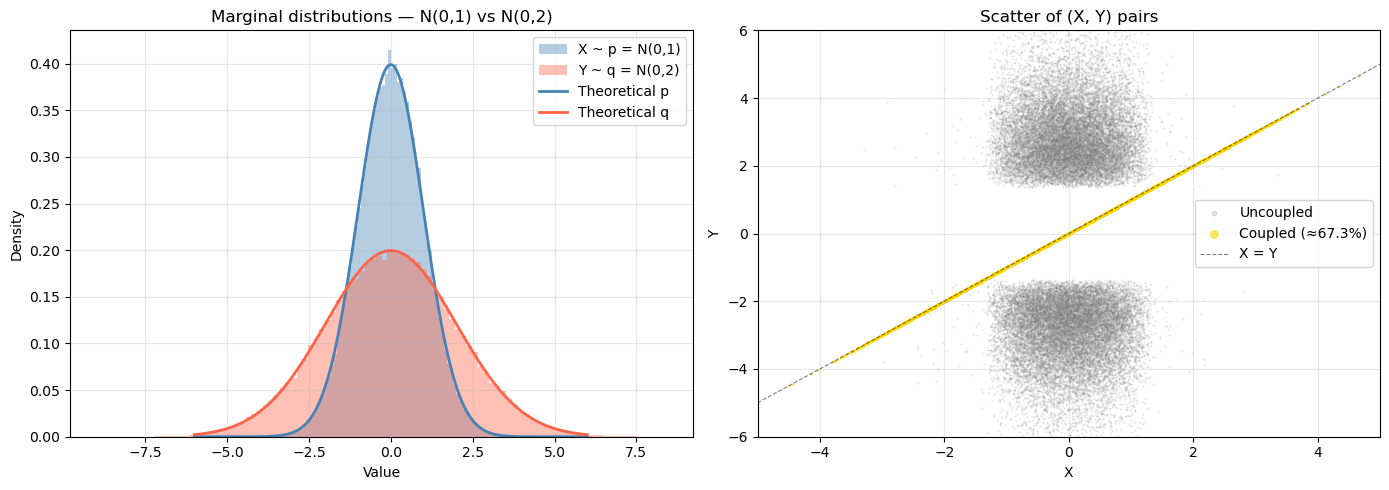

Coupled pairs: 67,316 / 100,000  (67.316%)


In [3]:
import matplotlib.pyplot as plt

x_range = np.linspace(-6, 6, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histograms with theoretical densities
ax = axes[0]
ax.hist(X_vals, bins=100, density=True, alpha=0.4, color="steelblue", label="X ~ p = N(0,1)")
ax.hist(Y_vals, bins=100, density=True, alpha=0.4, color="tomato",    label="Y ~ q = N(0,2)")

def p_densite_12(x): return np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
def q_densite_12(x): return np.exp(-x**2 / 8) / (2 * np.sqrt(2 * np.pi))

ax.plot(x_range, p_densite_12(x_range), "steelblue", linewidth=2, label="Theoretical p")
ax.plot(x_range, q_densite_12(x_range), "tomato",    linewidth=2, label="Theoretical q")
ax.set_title("Marginal distributions — N(0,1) vs N(0,2)")
ax.set_xlabel("Value"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.3)

# Right: scatter of (X, Y) pairs, highlight coupled ones
ax = axes[1]
coupled_mask = np.abs(X_vals - Y_vals) <= 0.01
ax.scatter(X_vals[~coupled_mask], Y_vals[~coupled_mask], s=0.3, alpha=0.2,
           color="gray", label="Uncoupled")
ax.scatter(X_vals[coupled_mask],  Y_vals[coupled_mask],  s=0.8, alpha=0.6,
           color="gold", label=f"Coupled (≈{coupled_mask.mean():.1%})")
ax.plot([-5, 5], [-5, 5], "k--", linewidth=0.8, alpha=0.5, label="X = Y")
ax.set_title("Scatter of (X, Y) pairs")
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.legend(markerscale=6); ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 5); ax.set_ylim(-6, 6)

plt.tight_layout()
plt.savefig("coupling_normal.png", dpi=150)
plt.show()
print(f"Coupled pairs: {coupled_mask.sum():,} / {len(X_vals):,}  ({coupled_mask.mean():.3%})")


### Modified Algorithm on $\mathcal{N}(0,1) \times \mathcal{U}([-1,1])$ with execution time variance

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def p_densite(x): return np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)  # N(0,1)
def q_densite(x): return np.where(np.abs(x) <= 1, 0.5, 0)         # U[-1,1]
def p_echantillon(): return np.random.normal()
def q_echantillon(): return np.random.uniform(-1, 1)

def test_variation_C(C_values, num_tests=1000, num_trials=200):
    results = []
    for C in tqdm(C_values):
        exec_times, proportions = [], []
        for _ in range(num_trials):
            X_vals, Y_vals = [], []
            t0 = time.time()
            for _ in range(num_tests):
                X, Y = thorisson_coupling(p_densite, p_echantillon, q_densite, q_echantillon, C)
                X_vals.append(X); Y_vals.append(Y)
            exec_times.append(time.time() - t0)
            proportions.append(erreur_egalite(np.array(X_vals), np.array(Y_vals), 0.01) / num_tests)
        results.append((C, np.mean(proportions), np.mean(exec_times), np.var(exec_times)))
    return results

C_values = np.arange(0.01, 1.01, 0.01)
results = test_variation_C(C_values)
C_vals, avg_prop, avg_time, var_time = zip(*results)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [27:43<00:00, 16.64s/it]


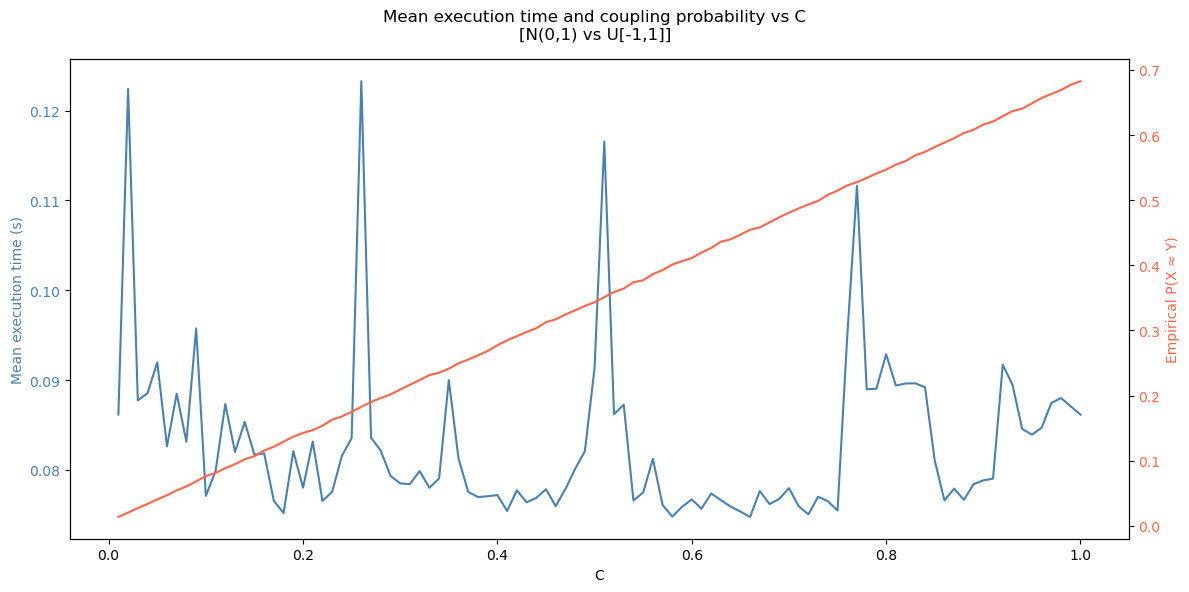

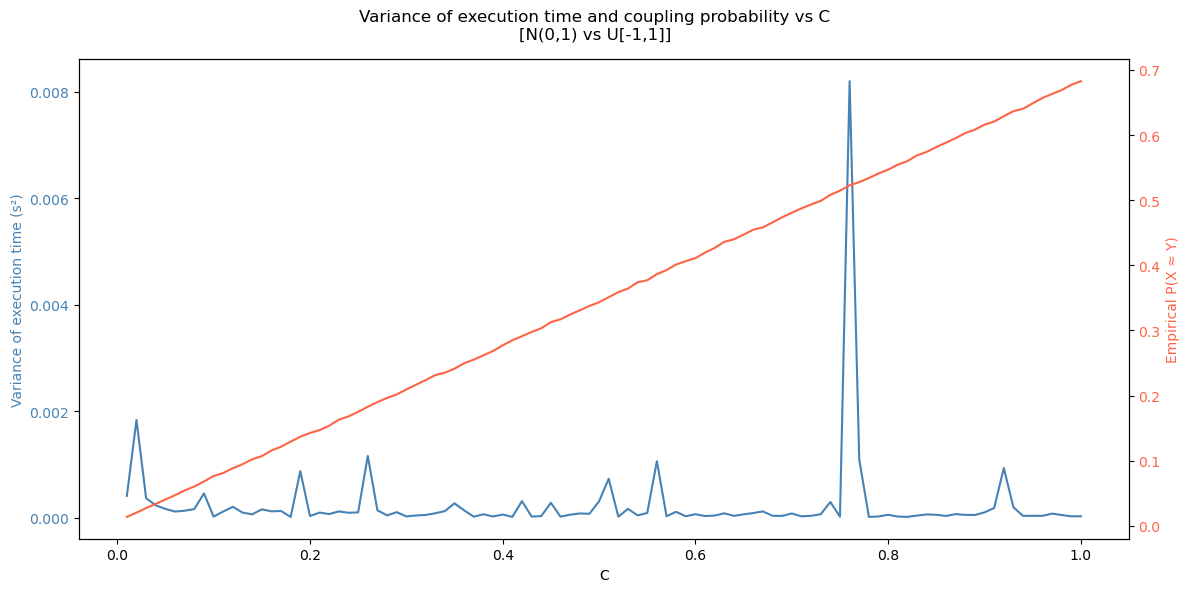

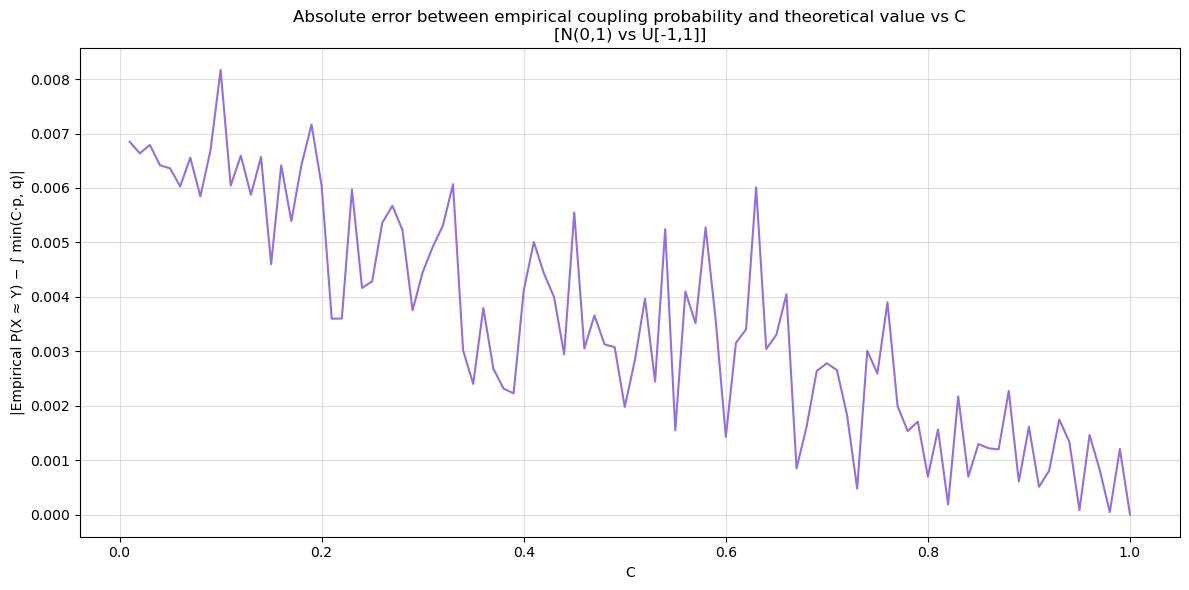

Best C (highest coupling probability): 1.00
  Empirical P(X ≈ Y) = 0.6827
  Mean exec time     = 0.0861 s
  Variance exec time = 0.000028 s²


In [5]:
# --- Plot 1: Mean execution time and coupling probability vs C ---
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("C")
ax1.set_ylabel("Mean execution time (s)", color="steelblue")
ax1.plot(C_vals, avg_time, color="steelblue", linewidth=1.5, label="Mean exec time")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.set_ylabel("Empirical P(X ≈ Y)", color="tomato")
ax2.plot(C_vals, avg_prop, color="tomato", linewidth=1.5, label="Coupling probability")
ax2.tick_params(axis="y", labelcolor="tomato")

fig.suptitle("Mean execution time and coupling probability vs C\n[N(0,1) vs U[-1,1]]")
fig.tight_layout()
plt.savefig("c_sweep_mean_time.png", dpi=150)
plt.show()

# --- Plot 2: Variance of execution time and coupling probability vs C ---
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("C")
ax1.set_ylabel("Variance of execution time (s²)", color="steelblue")
ax1.plot(C_vals, var_time, color="steelblue", linewidth=1.5, label="Variance exec time")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.set_ylabel("Empirical P(X ≈ Y)", color="tomato")
ax2.plot(C_vals, avg_prop, color="tomato", linewidth=1.5, label="Coupling probability")
ax2.tick_params(axis="y", labelcolor="tomato")

fig.suptitle("Variance of execution time and coupling probability vs C\n[N(0,1) vs U[-1,1]]")
fig.tight_layout()
plt.savefig("c_sweep_var_time.png", dpi=150)
plt.show()

# --- Plot 3: |empirical P(X ≈ Y) - theoretical integral| vs C ---
integral_vals = np.array([calcul_integral_min(p_densite, q_densite, C) for C in C_vals])
diff_vals = np.abs(np.array(avg_prop) - integral_vals)

plt.figure(figsize=(12, 6))
plt.plot(C_vals, diff_vals, color="mediumpurple", linewidth=1.5)
plt.xlabel("C")
plt.ylabel("|Empirical P(X ≈ Y) − ∫ min(C·p, q)|")
plt.title("Absolute error between empirical coupling probability and theoretical value vs C\n[N(0,1) vs U[-1,1]]")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("c_sweep_error.png", dpi=150)
plt.show()

best_C = C_vals[np.argmax(avg_prop)]
print(f"Best C (highest coupling probability): {best_C:.2f}")
print(f"  Empirical P(X ≈ Y) = {max(avg_prop):.4f}")
print(f"  Mean exec time     = {avg_time[np.argmax(avg_prop)]:.4f} s")
print(f"  Variance exec time = {var_time[np.argmax(avg_prop)]:.6f} s²")

### Algorithm with a shared proposal on $\mathcal{N}(0,1) \times \mathcal{N}(1,1)$

In [6]:
from scipy.stats import norm
import numpy as np

p     = lambda x: norm.pdf(x, loc=0.0, scale=1.0)
q     = lambda x: norm.pdf(x, loc=1.0, scale=1.0)
p_hat = lambda x: norm.pdf(x, loc=0.5, scale=np.sqrt(2))  # shared proposal
q_hat = p_hat

xs  = np.linspace(-10, 10, 10000)
M_p = np.max(p(xs) / p_hat(xs))
M_q = np.max(q(xs) / q_hat(xs))

def sample_from_gamma_hat():
    z = np.random.normal(0.5, np.sqrt(2))
    return z, z  # diagonal coupling

def sample_from_pq():
    return np.random.normal(0, 1), np.random.normal(1, 1)

def rejection_coupling():
    AX = AY = False
    while not (AX or AY):
        X1, Y1 = sample_from_gamma_hat()
        u = np.random.uniform()
        if u < p(X1) / (M_p * p_hat(X1)): AX = True
        if u < q(Y1) / (M_q * q_hat(Y1)): AY = True
    X2, Y2 = sample_from_pq()
    return (X1 if AX else X2), (Y1 if AY else Y2)

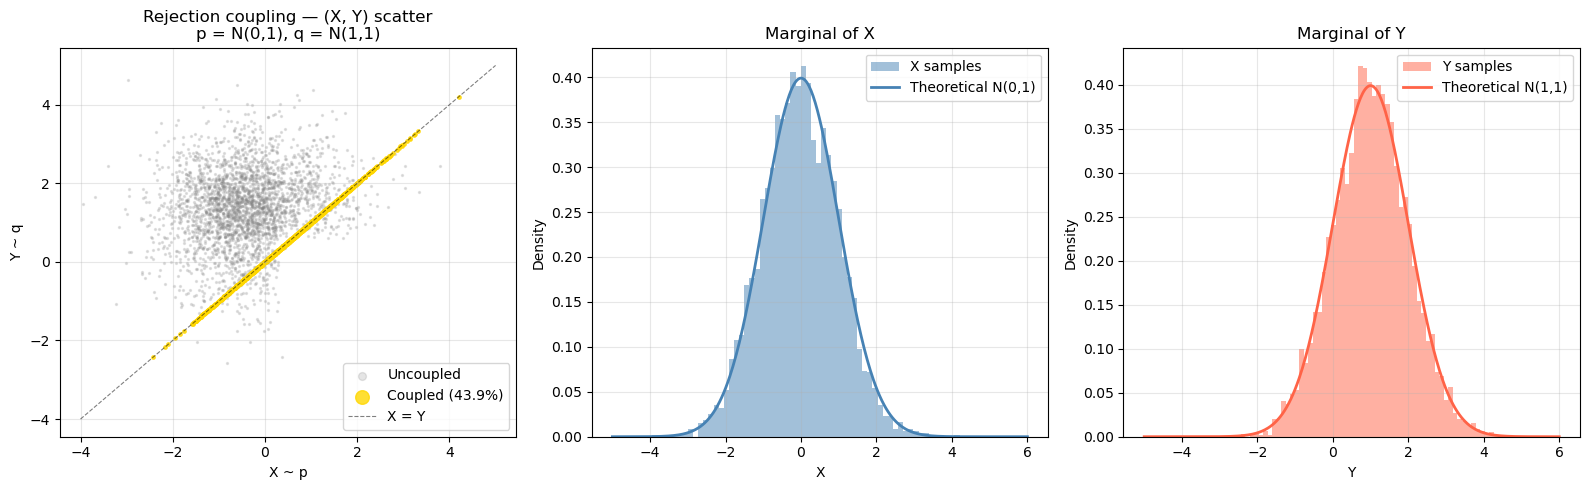

Estimated P(X = Y): 0.4392


In [7]:
import matplotlib.pyplot as plt
from scipy.stats import norm as scipy_norm

n_plot = 5000
samples = [rejection_coupling() for _ in range(n_plot)]
xs_rc, ys_rc = zip(*samples)
xs_rc = np.array(xs_rc); ys_rc = np.array(ys_rc)

coupled_rc = np.isclose(xs_rc, ys_rc, atol=1e-10)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: scatter (X, Y)
ax = axes[0]
ax.scatter(xs_rc[~coupled_rc], ys_rc[~coupled_rc], s=2, alpha=0.2, color="gray",
           label="Uncoupled")
ax.scatter(xs_rc[coupled_rc],  ys_rc[coupled_rc],  s=6, alpha=0.8, color="gold",
           label=f"Coupled ({coupled_rc.mean():.1%})")
ax.plot([-4, 5], [-4, 5], "k--", linewidth=0.8, alpha=0.5, label="X = Y")
ax.set_title("Rejection coupling — (X, Y) scatter\np = N(0,1), q = N(1,1)")
ax.set_xlabel("X ~ p"); ax.set_ylabel("Y ~ q")
ax.legend(markerscale=4); ax.grid(True, alpha=0.3)

# Centre: marginal of X
ax = axes[1]
x_range = np.linspace(-5, 6, 400)
ax.hist(xs_rc, bins=60, density=True, alpha=0.5, color="steelblue", label="X samples")
ax.plot(x_range, scipy_norm.pdf(x_range, 0, 1), "steelblue", linewidth=2,
        label="Theoretical N(0,1)")
ax.set_title("Marginal of X"); ax.set_xlabel("X"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.3)

# Right: marginal of Y
ax = axes[2]
ax.hist(ys_rc, bins=60, density=True, alpha=0.5, color="tomato", label="Y samples")
ax.plot(x_range, scipy_norm.pdf(x_range, 1, 1), "tomato", linewidth=2,
        label="Theoretical N(1,1)")
ax.set_title("Marginal of Y"); ax.set_xlabel("Y"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rejection_coupling_1d.png", dpi=150)
plt.show()
print(f"Estimated P(X = Y): {coupled_rc.mean():.4f}")


### Execution Time vs Dimension on multivariate normal

Dimensions: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:21<00:00, 13.65s/it]


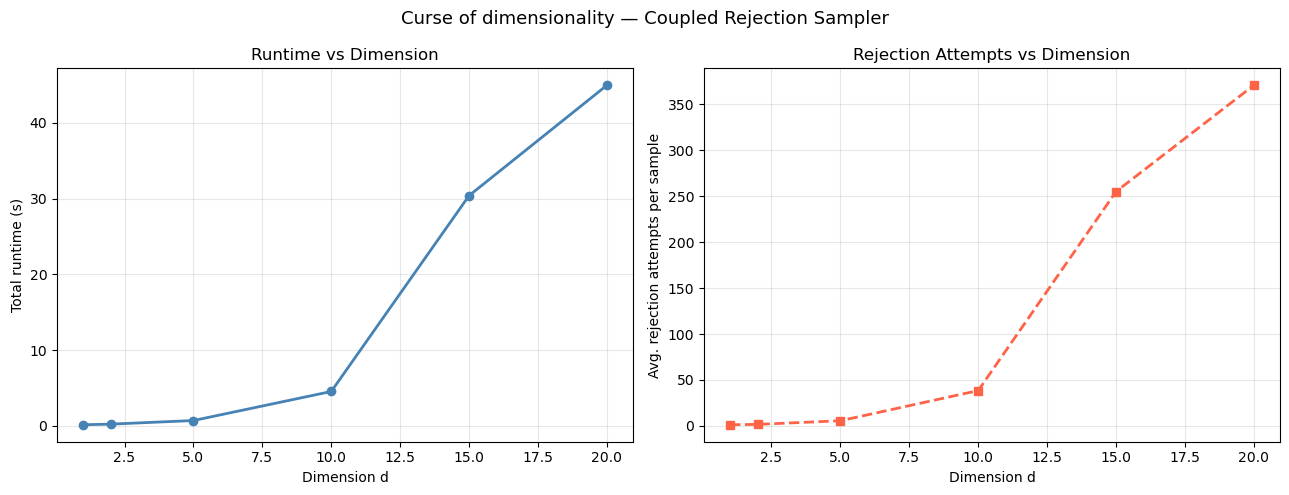

In [8]:
from scipy.stats import multivariate_normal
import time

def run_experiment(d, n_trials=1000):
    mu_p, mu_q = np.zeros(d), np.ones(d)
    mu_hat, cov_hat = 0.5 * (mu_p + mu_q), 2 * np.eye(d)
    mv_p   = multivariate_normal(mean=mu_p,   cov=np.eye(d))
    mv_q   = multivariate_normal(mean=mu_q,   cov=np.eye(d))
    mv_hat = multivariate_normal(mean=mu_hat, cov=cov_hat)

    zs = mv_hat.rvs(size=100000)
    M_p = np.max(mv_p.pdf(zs) / mv_hat.pdf(zs))
    M_q = np.max(mv_q.pdf(zs) / mv_hat.pdf(zs))

    def rejection_coupling():
        AX = AY = False; attempts = 0
        while not (AX or AY):
            attempts += 1
            z = mv_hat.rvs(); u = np.random.uniform()
            if u < mv_p.pdf(z) / (M_p * mv_hat.pdf(z)): AX = True
            if u < mv_q.pdf(z) / (M_q * mv_hat.pdf(z)): AY = True
        X = z if AX else mv_p.rvs()
        Y = z if AY else mv_q.rvs()
        return X, Y, attempts

    t0 = time.time()
    total_att = sum(rejection_coupling()[2] for _ in range(n_trials))
    return time.time() - t0, total_att / n_trials

# Lighter version of the dimension scaling experiment (n_trials=200 instead of 1000)
dimensions_light = [1, 2, 5, 10, 15, 20]
runtimes_light, avg_attempts_light = [], []

for d in tqdm(dimensions_light, desc="Dimensions"):
    rt, att = run_experiment(d, n_trials=200)
    runtimes_light.append(rt)
    avg_attempts_light.append(att)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(dimensions_light, runtimes_light, "o-", color="steelblue", linewidth=2)
axes[0].set_xlabel("Dimension d"); axes[0].set_ylabel("Total runtime (s)")
axes[0].set_title("Runtime vs Dimension")
axes[0].grid(True, alpha=0.3)

axes[1].plot(dimensions_light, avg_attempts_light, "s--", color="tomato", linewidth=2)
axes[1].set_xlabel("Dimension d"); axes[1].set_ylabel("Avg. rejection attempts per sample")
axes[1].set_title("Rejection Attempts vs Dimension")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Curse of dimensionality — Coupled Rejection Sampler", fontsize=13)
plt.tight_layout()
plt.savefig("rejection_coupling_hd.png", dpi=150)
plt.show()


### Reflexion Algorithm on $\mathcal{N}(\mu_p, \Sigma) \times \mathcal{N}(\mu_q,\Sigma)$

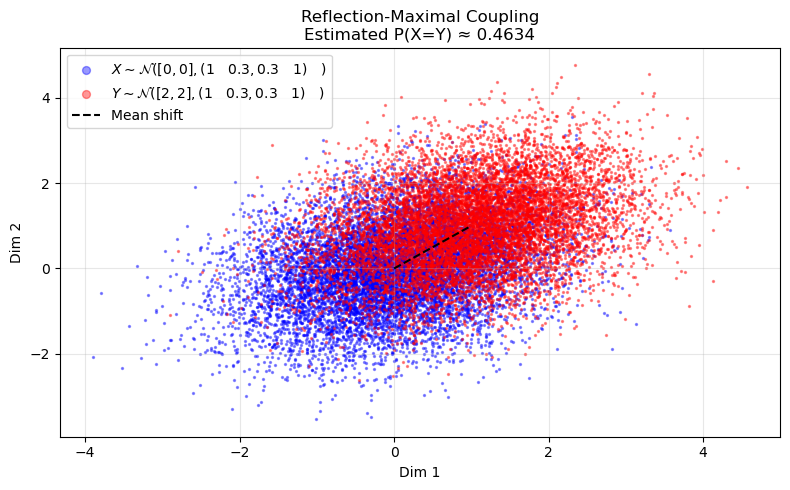

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def reflection_maximal_gaussian_coupling(mu_p, mu_q, Sigma, n_samples=10000):
    Sigma_inv  = np.linalg.inv(Sigma)
    Sigma_sqrt = np.linalg.cholesky(Sigma)
    delta      = mu_q - mu_p
    alpha      = np.exp(-0.5 * delta @ Sigma_inv @ delta)  # P(X = Y)

    samples_X, samples_Y, matches = [], [], 0
    for _ in range(n_samples):
        z = np.random.normal(0, 1, size=len(mu_p))
        x = mu_p + Sigma_sqrt @ z
        if np.random.uniform() < alpha:
            y = mu_q + Sigma_sqrt @ z   # coupled
            matches += 1
        else:
            reflect_z = z - 2 * ((z @ (Sigma_inv @ delta)) / (delta @ Sigma_inv @ delta)) * delta
            y = mu_q + Sigma_sqrt @ reflect_z
        samples_X.append(x); samples_Y.append(y)

    return np.array(samples_X), np.array(samples_Y), matches / n_samples

mu_p  = np.array([0.0, 0.0])
mu_q  = np.array([1.0, 1.0])
Sigma = np.array([[1.0, 0.3], [0.3, 1.0]])
X, Y, prob = reflection_maximal_gaussian_coupling(mu_p, mu_q, Sigma)

coupled_ref = np.array([np.allclose(X[i], Y[i], atol=1e-10) for i in range(len(X))], dtype=bool)

plt.figure(figsize=((8,5)))
label_p = r"$X \sim \mathcal{N}([0,0], (1 \quad 0.3, 0.3 \quad 1) \quad)$"
label_q = r"$Y \sim \mathcal{N}([2,2], (1 \quad 0.3, 0.3 \quad 1) \quad)$"
plt.scatter(X[~coupled_ref, 0], X[~coupled_ref, 1], s=2, alpha=0.4, color="blue", label=label_p)
plt.scatter(Y[~coupled_ref, 0], Y[~coupled_ref, 1], s=2, alpha=0.4, color="red" , label=label_q)
plt.plot([mu_p[0], mu_q[0]], [mu_p[1], mu_q[1]], "k--", linewidth=1.5, label="Mean shift")
plt.title(f"Reflection-Maximal Coupling\nEstimated P(X=Y) ≈ {prob:.4f}")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2"); plt.legend(markerscale=4); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("reflection_coupling.png", dpi=200); plt.show()

### Reflexion Algorithm on $\mathcal{N}(\mu_p, \Sigma_p) \times \mathcal{N}(\mu_q,\Sigma_q)$

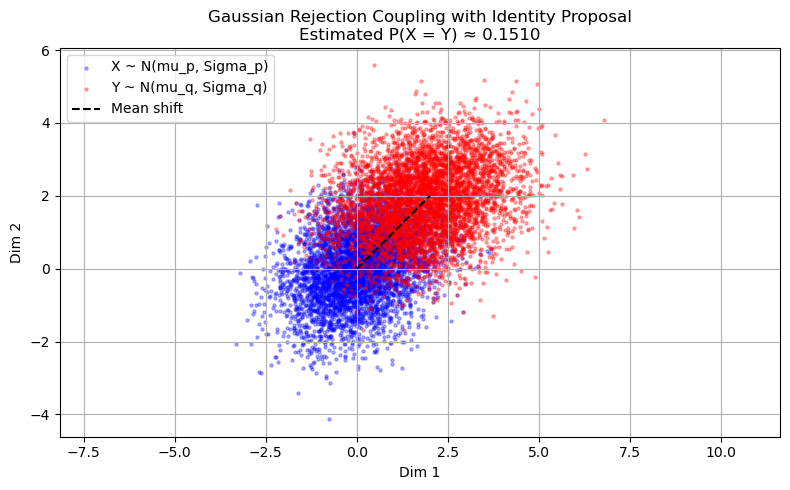

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from numpy.linalg import inv, eigvals, det

mu_p = np.array([0.0, 0.0])
mu_q = np.array([2.0, 2.0])

Sigma_p = np.array([[1.0, 0.3], [0.3, 1.0]])
Sigma_q = np.array([[1.5, 0.2], [0.2, 1.0]])

lambda_max = max(np.max(np.linalg.eigvals(Sigma_p)), np.max(np.linalg.eigvals(Sigma_q))) # As evoked in the article I take \Sigma_max that way.
Sigma_hat = lambda_max * np.eye(2)

proposal_mean = mu_p

# Compute M_p and M_q from determinant ratios, formula of the article
M_p = np.sqrt(det(Sigma_hat) / det(Sigma_p))
M_q = np.sqrt(det(Sigma_hat) / det(Sigma_q))

# Gaussian distributions
mv_p = multivariate_normal(mean=mu_p, cov=Sigma_p) # The ones we want to couple
mv_q = multivariate_normal(mean=mu_q, cov=Sigma_q)
mv_hat = multivariate_normal(mean=proposal_mean, cov=Sigma_hat) # Proposal

def gaussian_rejection_coupling():
    while True:
        z = mv_hat.rvs()
        u = np.random.uniform()

        w_p = mv_p.pdf(z) / mv_hat.pdf(z)
        w_q = mv_q.pdf(z) / mv_hat.pdf(z)

        if u < min(w_p / M_p, w_q / M_q):
            return z, z  # Coupled sample
        else:
            x = mv_p.rvs()
            y = mv_q.rvs()
            return x, y  # Independent fallback

n_samples = 5000
samples_X, samples_Y, coupled = [], [], 0

for _ in range(n_samples):
    x, y = gaussian_rejection_coupling()
    samples_X.append(x)
    samples_Y.append(y)
    if np.allclose(x, y, atol=1e-6):
        coupled += 1

samples_X, samples_Y = np.array(samples_X), np.array(samples_Y)

plt.figure(figsize=(8, 5))
plt.scatter(samples_X[:, 0], samples_X[:, 1], alpha=0.3, label='X ~ N(mu_p, Sigma_p)', color='blue', s=5)
plt.scatter(samples_Y[:, 0], samples_Y[:, 1], alpha=0.3, label='Y ~ N(mu_q, Sigma_q)',  color='red', s=5)
plt.plot([mu_p[0], mu_q[0]], [mu_p[1], mu_q[1]], 'k--', label='Mean shift')
plt.title(f"Gaussian Rejection Coupling with Identity Proposal\nEstimated P(X = Y) ≈ {coupled / n_samples:.4f}")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2"); plt.legend()
plt.axis("equal"); plt.grid(True); plt.tight_layout(); plt.savefig('gaussian_rejection_coupling.png', dpi=200); plt.show()